<a href="https://colab.research.google.com/github/pramodgurung10/AI-ML/blob/main/Worksheet6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import zipfile
import os

zip_file_path = '/content/drive/MyDrive/ConceptAI/FruitinAmazon.zip'
data_path = '/content/drive/MyDrive/ConceptAI'
destination_directory = os.path.dirname(data_path)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(destination_directory)

print(f"Successfully unzipped '{zip_file_path}' to '{destination_directory}'")

Successfully unzipped '/content/drive/MyDrive/ConceptAI/FruitinAmazon.zip' to '/content/drive/MyDrive'


In [3]:
pip install keras tensorflow

In [4]:
import tensorflow as tf
print(tf.keras.__version__)

3.13.2


#Simple CNN Implemented using Keras.

In [5]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
# Load a sample dataset (MNIST for simplicity)
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
# Normalize and reshape data
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = np.expand_dims(x_train, axis=-1) # Add channel dimension
x_test = np.expand_dims(x_test, axis=-1)
# Define a simple CNN model
model = keras.Sequential([
  layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
  layers.MaxPooling2D((2, 2)),
  layers.Conv2D(64, (3, 3), activation="relu"),
  layers.MaxPooling2D((2, 2)),
  layers.Flatten(),
  layers.Dense(128, activation="relu"),
  layers.Dense(10, activation="softmax") # 10 classes for MNIST digits
])
# Compile the model
model.compile(optimizer="adam",

loss="sparse_categorical_crossentropy",
metrics=["accuracy"])

# Train the model
model.fit(x_train, y_train, epochs=5, batch_size=32, validation_data=(x_test, y_test))
# Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")
# Make predictions
predictions = model.predict(x_test[:5])
predicted_labels = np.argmax(predictions, axis=1)
print("Predicted labels:", predicted_labels)
print("Actual labels: ", y_test[:5])

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 67s 35ms/step - accuracy: 0.9615 - loss: 0.1300 - val_accuracy: 0.9849 - val_loss: 0.0500
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 79s 33ms/step - accuracy: 0.9870 - loss: 0.0425 - val_accuracy: 0.9885 - val_loss: 0.0330
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 65s 35ms/step - accuracy: 0.9910 - loss: 0.0285 - val_accuracy: 0.9914 - val_loss: 0.0264
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 65s 34ms/step - accuracy: 0.9937 - loss: 0.0205 - val_accuracy: 0.9915 - val_loss: 0.0259
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 61s 33ms/step - accuracy: 0.9949 - loss: 0.0157 - val_accuracy: 0.9910 - val_loss: 0.0284
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9910 - loss: 0.0284
Test accuracy: 0.9910
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
Predicted labels: [7 2 1 0 4]
Actual labels:  [7 2 1 0 4]


#Implement an End to End CNN Model for Image Classification Task.

Task 1: Data Understanding and Visualization:

Download the Provided Data and Complete the following task.

1. Load and visualize images from a dataset stored in directories, where each subdirec-
tory represents a class. You are expected to write a code:

• Get the list of class directories from the train folder.

• Select one image randomly from each class.

• Display the images in a grid format with two rows using matplotlib.

• What did you Observe?

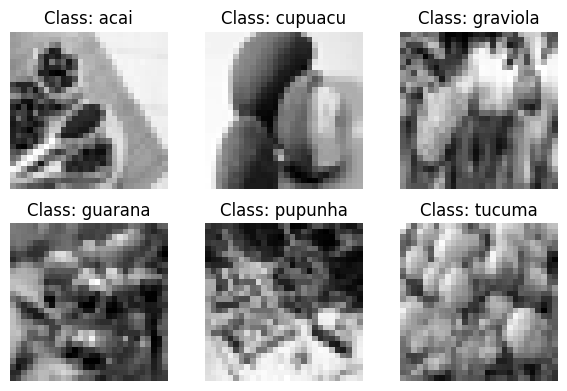

In [9]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# Define dataset paths (from previous cells)
train_dir = "/content/drive/MyDrive/FruitinAmazon/train"
img_height, img_width = 28, 28

# Get the list of class directories from the train folder
class_names = sorted(os.listdir(train_dir))

# Prepare to store selected images and their labels
selected_images = []
selected_labels = []

# Select one image randomly from each class
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        # Get all image filenames in the class directory
        image_files = [f for f in os.listdir(class_path) if f.endswith(('.png', '.jpg', '.jpeg'))]
        if image_files:
            # Select a random image from the current class
            random_image_file = random.choice(image_files)
            img_path = os.path.join(class_path, random_image_file)

            # Load image using PIL, convert to grayscale, resize, and normalize
            img = Image.open(img_path).convert("L")
            img = img.resize((img_width, img_height))
            img = np.array(img) / 255.0 # Normalize pixel values to [0,1]

            selected_images.append(img)
            selected_labels.append(class_name)

# Display the images in a grid format with two rows using matplotlib
# Calculate grid dimensions: 2 rows and ceil(num_classes / 2) columns
num_classes = len(selected_images)
num_cols = (num_classes + 1) // 2 # Integer division to get number of columns for two rows

plt.figure(figsize=(num_cols * 2, 2 * 2)) # Adjust figure size dynamically
for i in range(num_classes):
    plt.subplot(2, num_cols, i + 1)
    plt.imshow(selected_images[i], cmap='gray')
    plt.title(f"Class: {selected_labels[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

#2 Building an End-to-End Image Classifier with CNNs.

2.1 Data Understanding and Visualizations.

In [10]:
import os
# Define dataset path
train_dir = "/content/drive/MyDrive/FruitinAmazon/train"
# Get class names (subdirectories)
class_names = sorted(os.listdir(train_dir))
if not class_names:
  print("No class directories found in the train folder!")
else:
  print(f"Found {len(class_names)} classes: {class_names}")

Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


Check for Corrupted Images:

In [11]:
from PIL import Image, UnidentifiedImageError
corrupted_images = [] # List to store corrupted images path
# Loop through each class folder and check for corrupted images
for class_name in class_names:
  class_path = os.path.join(train_dir, class_name)
  if os.path.isdir(class_path): # Ensure it’s a valid directory
    images = os.listdir(class_path)
    for img_name in images:
      img_path = os.path.join(class_path, img_name)
      try:
        with Image.open(img_path) as img:
          img.verify() # Verify image integrity
      except (IOError, UnidentifiedImageError):
        corrupted_images.append(img_path)

# Print results
if corrupted_images:
  print("\nCorrupted Images Found:")
  for img in corrupted_images:
    print(img)
else:
  print("\nNo corrupted images found.")


No corrupted images found.


Count class Balance:

In [12]:
# Dictionary to store class counts
class_counts = {}
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        class_counts[class_name] = len(images) # Count images in each class

# Print Class Balance
print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>15}")
print("=" * 45)
for class_name, count in class_counts.items():
    print(f"{class_name:<25}{count:>15}")
print("=" * 45)


Class Distribution:
Class Name               Valid Image Count
acai                                  15
cupuacu                               15
graviola                              15
guarana                               15
pupunha                               15
tucuma                                15


• Select Random Images for Visualization:

In [13]:
import random
selected_images = [] # Store image paths
selected_labels = [] # Store corresponding class names
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if images: # Ensure the class folder is not empty
            selected_img = os.path.join(class_path, random.choice(images))
            selected_images.append(selected_img)
            selected_labels.append(class_name)

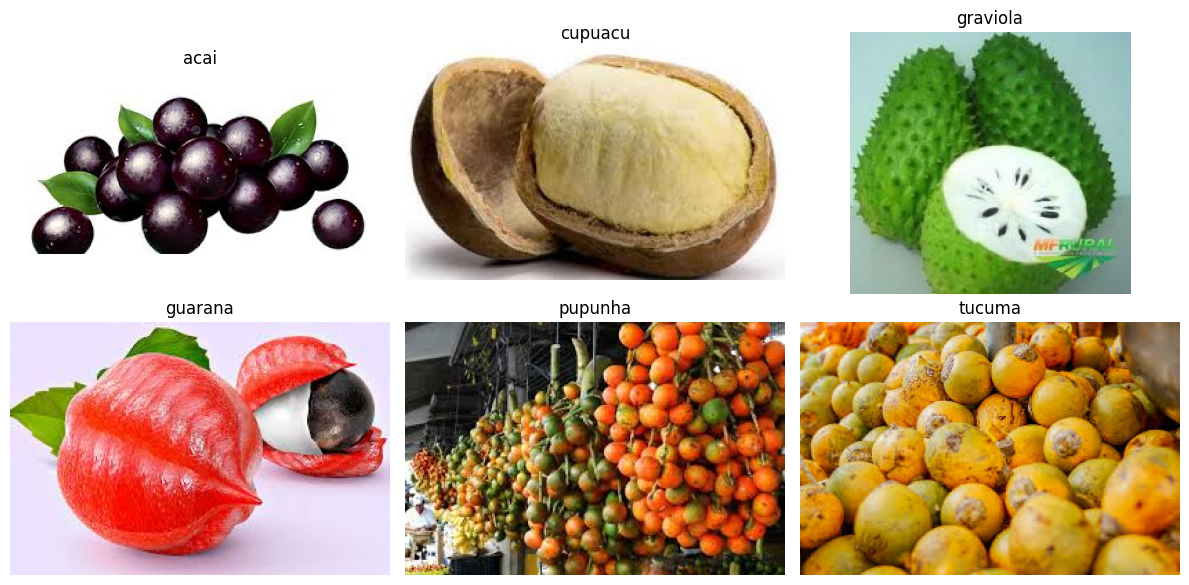

In [14]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
# Determine grid size
num_classes = len(selected_images)
cols = (num_classes + 1) // 2 # Determine columns
rows = 2 # Fixed rows for layout
fig, axes = plt.subplots(rows, cols, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i < num_classes:
        img = mpimg.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i])
        ax.axis("off")
    else:
        ax.axis("off") # Hide empty subplots
plt.tight_layout()
plt.show()

2.2 Data Generation and Pre - processing:

In [15]:
import keras
train_dir = "/content/drive/MyDrive/DevanagariHandwrittenDigitDataset/Train"
image_size = (28, 28)
batch_size = 32
train_ds, val_ds = keras.utils.image_dataset_from_directory(
train_dir,
validation_split=0.2,
subset="both",
seed=1337,
image_size=image_size,
batch_size=batch_size,
)

Found 17000 files belonging to 10 classes.
Using 13600 files for training.
Using 3400 files for validation.


In [16]:
for images, labels in train_ds.take(1): # Take one batch
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Images shape: (32, 28, 28, 3)
Labels shape: (32,)


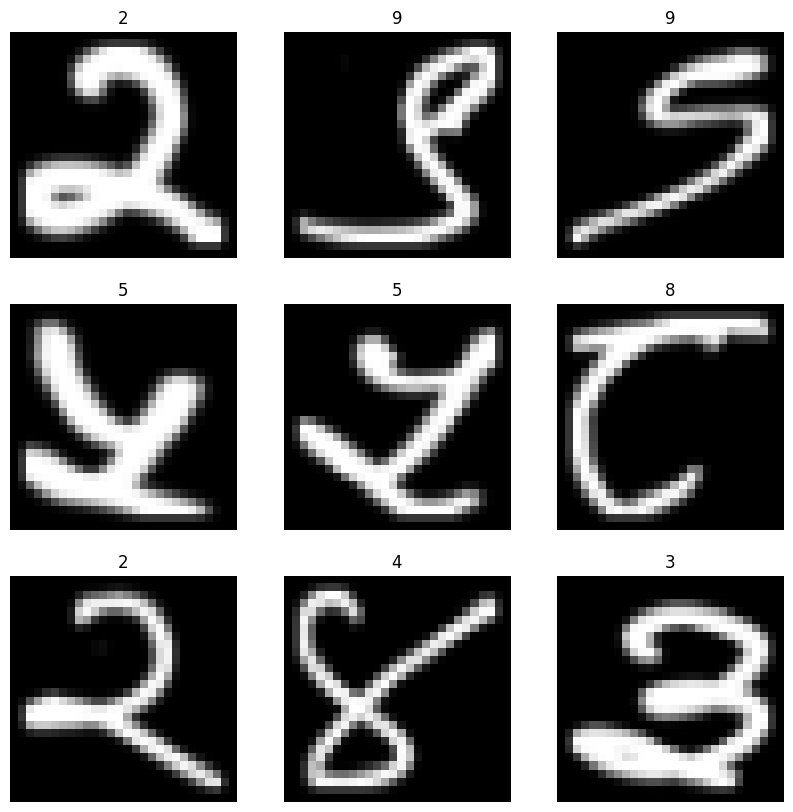

In [17]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(images[i]).astype("uint8"))
        plt.title(int(labels[i]))
        plt.axis("off")
plt.show()

#Using Keras ImageDataGenerator (Old API):

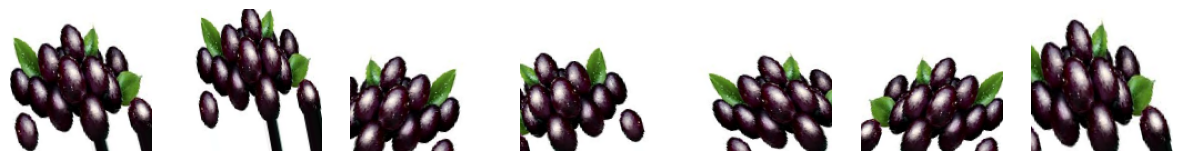

In [18]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
datagen = ImageDataGenerator(
    rotation_range=30, # Rotate images by up to 30 degrees
    width_shift_range=0.2, # Shift width by 20%
    height_shift_range=0.2, # Shift height by 20%
    shear_range=0.2, # Shear transformation
    zoom_range=0.2, # Zoom in/out by 20%
    horizontal_flip=True, # Flip images horizontally
    fill_mode='nearest' # Fill in missing pixels
)
# Load an example image
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np

# Using a placeholder image for now, as 'sample.jpg' is not present in the files.
# If you have an image, replace 'sample.jpg' with its path.
# For now, let's try to create a dummy image or use an existing one if available.
# Given the earlier steps, selected_images[0] might contain a valid path.
# Let's use the first selected image if available, otherwise create a dummy.
if 'selected_images' in locals() and selected_images:
    img = image.load_img(selected_images[0], target_size=(128, 128))
else:
    print("Warning: 'selected_images' not found or empty. Creating a dummy image.")
    # Create a dummy image if no real image path is available
    dummy_img_data = np.random.randint(0, 256, (128, 128, 3), dtype=np.uint8)
    img = Image.fromarray(dummy_img_data)

x = image.img_to_array(img) # Convert to NumPy array
x = np.expand_dims(x, axis=0)
# Generate augmented images
aug_iter = datagen.flow(x, batch_size=1)
# Visualize 7 augmented images
fig, ax = plt.subplots(1, 7, figsize=(15, 5))
for i in range(7):
    batch = next(aug_iter)
    ax[i].imshow(batch[0].astype('uint8'))
    ax[i].axis('off')
plt.show()

Using Keras tf.keras.layers.Random* (New API):

In [19]:
from tensorflow.keras import layers

# This is a sample implementation, Thus I only use two augmentation, you can use more than two
# augmentation type for your project. Please check keras documentations for other available
# augmentation techniques.
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
]

def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

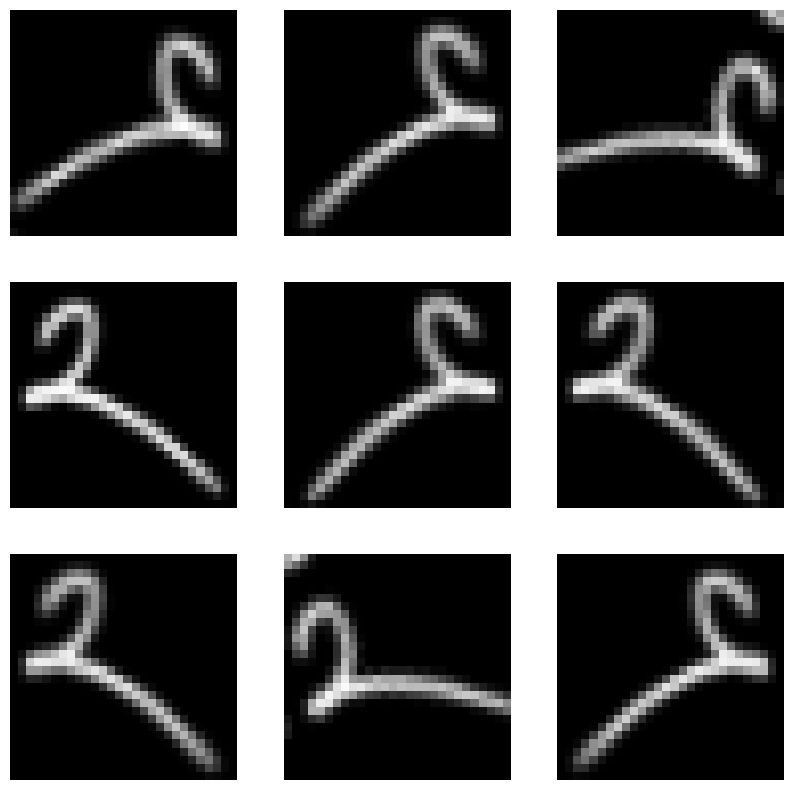

In [20]:
model = keras.Sequential([
  layers.Input(shape=(128, 128, 3)),
  *data_augmentation_layers, # Include augmentation before the model layers
  layers.Conv2D(32, (3,3), activation="relu"),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(10, activation="softmax")
])

plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
  for i in range(9):
    augmented_images = data_augmentation(images)
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(np.array(augmented_images[0]).astype("uint8"))
    plt.axis("off")

3. Data Pre - processing: Scaling the data with Keras:

In [21]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

# Load a sample dataset (MNIST for simplicity)
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize and reshape data
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = np.expand_dims(x_train, axis=-1) # Add channel dimension
x_test = np.expand_dims(x_test, axis=-1)

# Define a simple CNN model
model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax") # 10 classes for MNIST digits
])

# Compile the model
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

# Train the model
model.fit(x_train, y_train, epochs=5, batch_size=32, validation_data=(x_test, y_test))

# Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

# Make predictions
predictions = model.predict(x_test[:5])
predicted_labels = np.argmax(predictions, axis=1)
print("Predicted labels:", predicted_labels)
print("Actual labels: ", y_test[:5])

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 66s 34ms/step - accuracy: 0.9636 - loss: 0.1222 - val_accuracy: 0.9862 - val_loss: 0.0443
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 79s 33ms/step - accuracy: 0.9862 - loss: 0.0429 - val_accuracy: 0.9859 - val_loss: 0.0436
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 33ms/step - accuracy: 0.9912 - loss: 0.0282 - val_accuracy: 0.9897 - val_loss: 0.0328
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 33ms/step - accuracy: 0.9934 - loss: 0.0205 - val_accuracy: 0.9910 - val_loss: 0.0289
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 61s 33ms/step - accuracy: 0.9948 - loss: 0.0155 - val_accuracy: 0.9906 - val_loss: 0.0347
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9906 - loss: 0.0347
Test accuracy: 0.9906
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
Predicted labels: [7 2 1 0 4]
Actual labels:  [7 2 1 0 4]


#Batch Normalization Layer

1. BatchNormalization Class in Keras:

In [31]:
from tensorflow.keras.layers import BatchNormalization
layer = BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001, center=True, scale=True,
  beta_initializer="zeros", gamma_initializer="ones")

In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Activation, Lambda
from tensorflow.keras import layers

data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
]

def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

# Define the model using the Sequential API with a list of layers
model = Sequential([
    # Data augmentation applied using Lambda layer
    Lambda(data_augmentation, input_shape=(224, 224, 3)),
    # Rescaling layer to normalize pixel values
    layers.Rescaling(1./255),

    # First Convolutional Block
    Conv2D(32, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Second Convolutional Block
    Conv2D(64, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Third Convolutional Block
    Conv2D(128, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Fourth Convolutional Block
    Conv2D(256, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Flatten the output of the last Conv2D layer
    Flatten(),

    # First Fully Connected Layer
    Dense(512, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # Second Fully Connected Layer
    Dense(256, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # Third Fully Connected Layer
    Dense(128, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # Fourth Fully Connected Layer
    Dense(64, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # Output Layer with 10 neurons (for classification task with 10 classes)
    Dense(10, activation='softmax')
])

# Compile the model with Adam optimizer, sparse categorical crossentropy loss, and accuracy as the metric
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy', # Use this for integer labels
              metrics=['accuracy'])

# Summary of the model
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_1 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 50176)          │             

 Total params: 26,257,930 (100.17 MB)

 Trainable params: 26,255,050 (100.16 MB)

 Non-trainable params: 2,880 (11.25 KB)

#4 Image classification via fine-tuning with VGG16

1. Load the Pre - trained Model:

In this step, you load a pre-trained model (e.g., VGG16) without the final classification layer.
This
allows you to use the learned features from a large dataset (e.g., ImageNet) and fine-tune the model for
your own task.

In [33]:
from tensorflow.keras.applications import VGG16
# Load the VGG16 model pre-trained on ImageNet, without the top classification layer
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

2. Freeze the Layers:

In this step, you freeze the layers of the pre-trained model, so their weights do not get updated during
training. This helps in preserving the knowledge from the pre-training on ImageNet.

In [39]:
# Freeze the layers of the base model
for layer in base_model.layers:
    layer.trainable = False

In [46]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    "/content/drive/MyDrive/FruitinAmazon/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    "/content/drive/MyDrive/FruitinAmazon/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

test_datagen = ImageDataGenerator(rescale=1./255)

test_data = test_datagen.flow_from_directory(
    "/content/drive/MyDrive/FruitinAmazon/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 72 images belonging to 6 classes.
Found 18 images belonging to 6 classes.
Found 30 images belonging to 6 classes.


3. Add a Custom Layers:




In [47]:
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

# Add custom layers on top of the pre-trained model
x = base_model.output
x = GlobalAveragePooling2D()(x) # Reduces dimensions (height, width) to a single vector per image
x = Dense(1024, activation='relu')(x) # Fully connected layer with 1024 neurons

# Get the number of classes from the train_data generator (which is 6 for the fruit dataset)
num_classes = train_data.num_classes # This will be 6 based on previous output
x = Dense(num_classes, activation='softmax')(x) # Output layer for the fruit classes (with softmax for multi-class classification)

4. Create the Final Model:

In [48]:
from tensorflow.keras.models import Model
# Create the final model
model = Model(inputs=base_model.input, outputs=x)

5. Compile and Fit the model.

In [49]:
from tensorflow.keras.optimizers import Adam

# Compile the model
model.compile(optimizer=Adam(),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Define the number of epochs (can be adjusted)
epochs = 10

# Fit the model
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=epochs
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 70s 32s/step - accuracy: 0.1806 - loss: 1.9773 - val_accuracy: 0.4444 - val_loss: 1.7129
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 58s 19s/step - accuracy: 0.3472 - loss: 1.6468 - val_accuracy: 0.3333 - val_loss: 1.6407
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 80s 18s/step - accuracy: 0.2778 - loss: 1.5247 - val_accuracy: 0.3889 - val_loss: 1.5131
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 56s 26s/step - accuracy: 0.5694 - loss: 1.2815 - val_accuracy: 0.6111 - val_loss: 1.4117
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 58s 18s/step - accuracy: 0.5972 - loss: 1.1972 - val_accuracy: 0.6111 - val_loss: 1.3632
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 55s 25s/step - accuracy: 0.6806 - loss: 1.0578 - val_accuracy: 0.5556 - val_loss: 1.2790
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 64s 22s/step - accuracy: 0.7222 - loss: 0.9588 - val_accuracy: 0.5556 - val_loss: 1.2248
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 55s 18s/step - accuracy: 0.7778 - loss: 0.8502 - val_accuracy: 0.6667 - val_loss: 1.1625


#5 Task - 2:

To - Do:

    • Implement transfer learning using a pre-trained model trained on ImageNet weights, freeze the
    layers of the model, and fit it only on the output layer to classify the fruits dataset.

    • Evaluate the model’s performance and generate an inference output and classification report.

    • Did the performance improved compared to training from scratch.

Expected Deliverables:

    • Trained Model: A trained model with the frozen layers and fine-tuned output layer.

    • Inference Output: Predicted class labels for the validation dataset.

    • Classification Report: A detailed classification report showing the performance of the model for
    each class.

In [52]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/ConceptAI/FruitinAmazon.zip"
extract_path = "/content/drive/MyDrive/ConceptAI"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Done extracting!")

Done extracting!


In [53]:
import os

test_dir = "/content/drive/MyDrive/FruitinAmazon/test"

# Check if the directory exists before listing its contents
if os.path.exists(test_dir):
    print(os.listdir(test_dir))
else:
    print(f"Error: Directory not found at {test_dir}")


['cupuacu', 'acai', 'pupunha', 'graviola', 'tucuma', 'guarana']


In [54]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    "/content/drive/MyDrive/FruitinAmazon/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    "/content/drive/MyDrive/FruitinAmazon/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

test_datagen = ImageDataGenerator(rescale=1./255)

test_data = test_datagen.flow_from_directory(
    "/content/drive/MyDrive/FruitinAmazon/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 72 images belonging to 6 classes.
Found 18 images belonging to 6 classes.
Found 30 images belonging to 6 classes.


In [55]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze layers
for layer in base_model.layers:
    layer.trainable = False

# Custom head
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(train_data.num_classes, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=output)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [56]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.2083 - loss: 2.2617 - val_accuracy: 0.3889 - val_loss: 1.4371
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.5139 - loss: 1.3348 - val_accuracy: 0.7222 - val_loss: 1.0410
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.7500 - loss: 0.8062 - val_accuracy: 0.7222 - val_loss: 0.8285
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.7778 - loss: 0.5832 - val_accuracy: 0.7778 - val_loss: 0.6475
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step - accuracy: 0.8194 - loss: 0.4898 - val_accuracy: 0.8889 - val_loss: 0.5068
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.9167 - loss: 0.3305 - val_accuracy: 0.8889 - val_loss: 0.4682
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.9306 - loss: 0.2950 - val_accuracy: 0.8333 - val_loss: 0.4777
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.9444 - loss: 0.1792 - val_accuracy: 0.7778 - val_loss: 0.5173
Epoch 9/10
3/3 

In [57]:
loss, acc = model.evaluate(test_data)
print("Test Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.9000 - loss: 0.2822
Test Accuracy: 0.8999999761581421


In [58]:
from sklearn.metrics import classification_report
import numpy as np

predictions = model.predict(test_data)
y_pred = np.argmax(predictions, axis=1)

print(classification_report(
    test_data.classes,
    y_pred,
    target_names=list(test_data.class_indices.keys())
))

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
              precision    recall  f1-score   support

        acai       1.00      0.80      0.89         5
     cupuacu       0.80      0.80      0.80         5
    graviola       1.00      1.00      1.00         5
     guarana       1.00      1.00      1.00         5
     pupunha       0.83      1.00      0.91         5
      tucuma       0.80      0.80      0.80         5

    accuracy                           0.90        30
   macro avg       0.91      0.90      0.90        30
weighted avg       0.91      0.90      0.90        30



In [59]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = "/content/drive/MyDrive/FruitinAmazon/train/pupunha/images (1).jpeg"  # change this

img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

pred = model.predict(img_array)
pred_class = list(train_data.class_indices.keys())[np.argmax(pred)]

print("Prediction:", pred_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Prediction: pupunha


In [60]:
from tensorflow.keras import Sequential

scratch_model = Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(train_data.num_classes, activation='softmax')
])

scratch_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

scratch_model.fit(train_data, validation_data=val_data, epochs=10)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 4s/step - accuracy: 0.1667 - loss: 18.5349 - val_accuracy: 0.1667 - val_loss: 12.1706
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 3s/step - accuracy: 0.2083 - loss: 7.0491 - val_accuracy: 0.2778 - val_loss: 3.5807
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 3s/step - accuracy: 0.3889 - loss: 2.0708 - val_accuracy: 0.2778 - val_loss: 1.6187
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.5417 - loss: 1.2465 - val_accuracy: 0.5000 - val_loss: 1.2397
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.7500 - loss: 0.8774 - val_accuracy: 0.6111 - val_loss: 1.5081
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step - accuracy: 0.8333 - loss: 0.5623 - val_accuracy: 0.6111 - val_loss: 1.2247
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.9444 - loss: 0.3083 - val_accuracy: 0.5556 - val_loss: 1.0523
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 4s/step - accuracy: 0.9306 - loss: 0.2208 - val_accuracy: 0.4444 - val_loss: 1.1033
Epoch 9/10
3

In [61]:
predictions = scratch_model.predict(test_data)
y_pred = np.argmax(predictions, axis=1)

print(classification_report(
    test_data.classes,
    y_pred,
    target_names=list(test_data.class_indices.keys())
))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
              precision    recall  f1-score   support

        acai       0.75      0.60      0.67         5
     cupuacu       0.43      0.60      0.50         5
    graviola       0.62      1.00      0.77         5
     guarana       0.67      0.80      0.73         5
     pupunha       1.00      0.60      0.75         5
      tucuma       1.00      0.40      0.57         5

    accuracy                           0.67        30
   macro avg       0.75      0.67      0.66        30
weighted avg       0.75      0.67      0.66        30



In [62]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = "/content/drive/MyDrive/FruitinAmazon/train/pupunha/images (1).jpeg" # change this

img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

pred = scratch_model.predict(img_array)
pred_class = list(train_data.class_indices.keys())[np.argmax(pred)]

print("Prediction:", pred_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
Prediction: guarana
